Task 1 This notebook builds reproducible: machine learning pipelines by combining
feature engineering, preprocessing, and the model. Random states are fixed
where applicable. The same pipeline can be used for training and prediction. Fully Reproducible Pipelines


In [18]:
# Task 2: Load the dataset again

from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np

adult = fetch_openml('adult', version=2, as_frame=True)

df = adult.frame

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


Dataset loaded successfully!
Dataset shape: (48842, 15)


In [19]:
# Task 1: Check library versions

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.5
NumPy version: 2.5.2


In [20]:
# Task 1: Set random state for reproducibility
RANDOM_STATE=42
print("Random state:", RANDOM_STATE)



Random state: 42


In [39]:
# Task 2: Separate features and target

X = df.drop('class', axis=1)

y = df['class'].map({
    '<=50K': 0,
    '>50K': 1
})

print("Features and target created successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)# Task 1: Separate features and target

X = df.drop('class', axis=1)
y = df['class'].map({'<=50K': 0, '>50K': 1})

print("Features and target separated successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target created successfully!
X shape: (48842, 14)
y shape: (48842,)
Features and target separated successfully!
X shape: (48842, 14)
y shape: (48842,)


In [57]:
# Task 2: Create training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39073, 14)
Testing data: (9769, 14)


In [58]:
# Task 1: Create feature engineering function

from sklearn.preprocessing import FunctionTransformer

def create_features(X):
    X = X.copy()

    # Create age groups
    X['age_group'] = pd.cut(
        X['age'],
        bins=[0, 25, 35, 45, 55, 100],
        labels=['18-25', '26-35', '36-45', '46-55', '56+']
    )

    # Create working hours groups
    X['hours_group'] = pd.cut(
        X['hours-per-week'],
        bins=[0, 30, 40, 50, 100],
        labels=['Low', 'Normal', 'High', 'Very High']
    )

    # Create capital gain flag
    X['has_capital_gain'] = (X['capital-gain'] > 0).astype(int)

    # Apply log transformation
    X['log_capital_gain'] = np.log1p(X['capital-gain'])

    # Create higher education flag
    X['higher_education'] = (X['education-num'] >= 13).astype(int)

    # Create education and working hours interaction
    X['education_hours_interaction'] = (
        X['education-num'] * X['hours-per-week']
    )

    return X

print("Feature engineering function created successfully!")

Feature engineering function created successfully!


In [59]:
# Task 1: Select numerical and categorical features

numeric_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'has_capital_gain',
    'log_capital_gain',
    'higher_education',
    'education_hours_interaction'
]

categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_group',
    'hours_group'
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 10
Categorical features: 10


In [60]:
# Task 1: Create preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocess numerical features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocess categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [61]:
# Task 1: Combine feature engineering and preprocessing

from sklearn.preprocessing import FunctionTransformer

feature_engineering = FunctionTransformer(create_features)

full_preprocessor = Pipeline([
    ('feature_engineering', feature_engineering),
    ('preprocessing', preprocessor)
])

print("Full preprocessing pipeline created successfully!")

Full preprocessing pipeline created successfully!


In [62]:
# Task 1: Create the machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Create the three machine learning models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

print("Three models created successfully!")

Three models created successfully!


In [63]:
# Task 1: Import Pipeline

from sklearn.pipeline import Pipeline

print("Pipeline imported successfully!")

Pipeline imported successfully!


In [64]:
# Task 1: Create the machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Create the three machine learning models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

print("Three models created successfully!")

Three models created successfully!


In [65]:
# Task 1: Import Pipeline

from sklearn.pipeline import Pipeline

print("Pipeline imported successfully!")

Pipeline imported successfully!


In [66]:
# Task 1: Create feature engineering function

def create_features(X):
    X = X.copy()

    # Create age groups
    X['age_group'] = pd.cut(
        X['age'],
        bins=[0, 25, 35, 45, 55, 100],
        labels=['18-25', '26-35', '36-45', '46-55', '56+']
    )

    # Create working hours groups
    X['hours_group'] = pd.cut(
        X['hours-per-week'],
        bins=[0, 30, 40, 50, 100],
        labels=['Low', 'Normal', 'High', 'Very High']
    )

    # Create capital gain flag
    X['has_capital_gain'] = (X['capital-gain'] > 0).astype(int)

    # Apply log transformation
    X['log_capital_gain'] = np.log1p(X['capital-gain'])

    # Create higher education flag
    X['higher_education'] = (X['education-num'] >= 13).astype(int)

    # Create education and working hours interaction
    X['education_hours_interaction'] = (
        X['education-num'] * X['hours-per-week']
    )

    return X

print("Feature engineering function created successfully!")

Feature engineering function created successfully!


In [67]:
# Task 1: Select numerical and categorical features

numeric_features = [
    'age',
    'fnlwgt',
    'education-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'has_capital_gain',
    'log_capital_gain',
    'higher_education',
    'education_hours_interaction'
]

categorical_features = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'age_group',
    'hours_group'
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 10
Categorical features: 10


In [68]:
# Task 1: Create preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical features preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical features preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [69]:
# Task 1: Combine feature engineering and preprocessing

from sklearn.preprocessing import FunctionTransformer

feature_engineering = FunctionTransformer(create_features)

full_preprocessor = Pipeline([
    ('feature_engineering', feature_engineering),
    ('preprocessing', preprocessor)
])

print("Full preprocessor created successfully!")

Full preprocessor created successfully!


In [70]:
# Task 1: Create the machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

print("Models created successfully!")

Models created successfully!


In [71]:
# Task 1: Import Pipeline

from sklearn.pipeline import Pipeline

print("Pipeline imported successfully!")

Pipeline imported successfully!


In [72]:
# Task 1: Create complete pipelines with preprocessing and models

model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline([
        ('preprocessing', full_preprocessor),
        ('model', model)
    ])

print("Complete model pipelines created successfully!")

Complete model pipelines created successfully!


Reproducibility

 We used random_state = 42 to get the same results again.
Preprocessing and the model are combined in one Pipeline.
 Library versions are written above.
 To reproduce the work, run the notebook cells in order.

In [73]:
# Task 2: Create cross-validation strategy

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold Stratified Cross-Validation created successfully!")

5-fold Stratified Cross-Validation created successfully!


In [74]:
# Task 2: Hyperparameter Search for Logistic Regression

from sklearn.model_selection import GridSearchCV

logistic_params = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.1, 1, 10]
}

logistic_search = GridSearchCV(
    model_pipelines['Logistic Regression'],
    param_grid=logistic_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

logistic_search.fit(X_train, y_train)

print("Best parameters:", logistic_search.best_params_)
print("Best score:", logistic_search.best_score_)

c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Tooba Iqbal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\

Best parameters: {'model__C': 10, 'model__penalty': 'l2'}
Best score: 0.856883039300984


In [76]:
# Task 2: Hyperparameter Search for Random Forest

rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_leaf': [1, 2]
}

rf_search = GridSearchCV(
    model_pipelines['Random Forest'],
    param_grid=rf_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best score:", rf_search.best_score_)

Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best score: 0.861361868169424


In [77]:
# Task 2: Hyperparameter Search for Gradient Boosting

gb_params = {
    'model__learning_rate': [0.01, 0.1],
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5]
}

gb_search = GridSearchCV(
    model_pipelines['Gradient Boosting'],
    param_grid=gb_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best parameters:", gb_search.best_params_)
print("Best score:", gb_search.best_score_)

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best score: 0.8729300183194002


In [78]:
# Task 2: Compare the best scores

print("Logistic Regression:", logistic_search.best_score_)
print("Random Forest:", rf_search.best_score_)
print("Gradient Boosting:", gb_search.best_score_)

Logistic Regression: 0.856883039300984
Random Forest: 0.861361868169424
Gradient Boosting: 0.8729300183194002


In [79]:
# Task 3: Calculate Learning Curve

from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, validation_scores = learning_curve(
    gb_search.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

print("Learning curve calculated successfully!")

Learning curve calculated successfully!


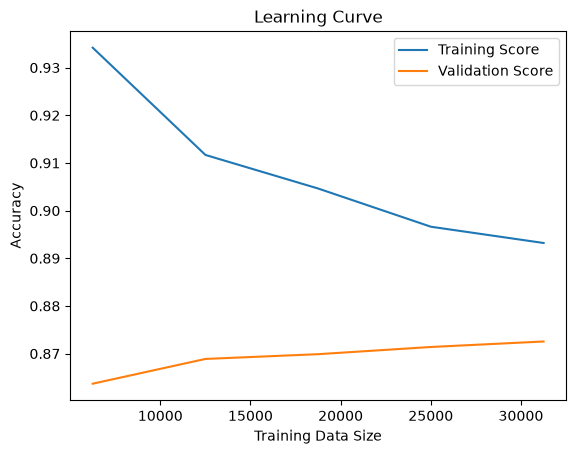

In [80]:
# Task 3: Plot Learning Curve

import matplotlib.pyplot as plt

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, validation_scores.mean(axis=1), label="Validation Score")

plt.xlabel("Training Data Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

Task 3 Conclusion

The learning curve shows some overfitting because the training score is higher than the validation score.

However, the validation score improves as the training data increases.

More training data and regularization can help reduce overfitting.

In [81]:
# Task 4: Calculate Brier Score

from sklearn.metrics import brier_score_loss

# Get predicted probabilities
y_prob = gb_search.best_estimator_.predict_proba(X_test)[:, 1]

# Calculate Brier Score
brier_score = brier_score_loss(y_test, y_prob)

print("Brier Score:", brier_score)

Brier Score: 0.08703117169437667


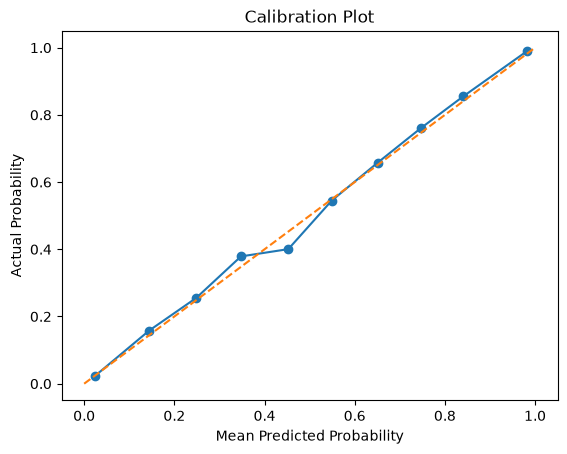

In [82]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Plot")
plt.show()

In [83]:
from sklearn.metrics import confusion_matrix, f1_score

thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Threshold:", threshold)
    print("Confusion Matrix:")
    print(cm)
    print("F1 Score:", f1)
    print("--------------------")

Threshold: 0.3
Confusion Matrix:
[[6457  974]
 [ 435 1903]]
F1 Score: 0.7298178331735379
--------------------
Threshold: 0.5
Confusion Matrix:
[[7027  404]
 [ 797 1541]]
F1 Score: 0.7195890730796171
--------------------
Threshold: 0.7
Confusion Matrix:
[[7303  128]
 [1217 1121]]
F1 Score: 0.6250348480624477
--------------------


In [84]:
for threshold in [0.3, 0.5, 0.7]:
    y_pred = (y_prob >= threshold).astype(int)
    
    print("Threshold:", threshold)
    print("F1 Score:", f1_score(y_test, y_pred))
    print()

Threshold: 0.3
F1 Score: 0.7298178331735379

Threshold: 0.5
F1 Score: 0.7195890730796171

Threshold: 0.7
F1 Score: 0.6250348480624477



In [85]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Threshold:", threshold)
    print("Confusion Matrix:")
    print(cm)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("--------------------")

Threshold: 0.3
Confusion Matrix:
[[6457  974]
 [ 435 1903]]
Precision: 0.6614529023288147
Recall: 0.8139435414884517
F1 Score: 0.7298178331735379
--------------------
Threshold: 0.5
Confusion Matrix:
[[7027  404]
 [ 797 1541]]
Precision: 0.7922879177377892
Recall: 0.6591103507271172
F1 Score: 0.7195890730796171
--------------------
Threshold: 0.7
Confusion Matrix:
[[7303  128]
 [1217 1121]]
Precision: 0.8975180144115292
Recall: 0.47946963216424293
F1 Score: 0.6250348480624477
--------------------


 Conclusion

The Brier Score was 0.087, which shows that the model's predicted probabilities were good. We tested three different thresholds: 0.3, 0.5, and 0.7**. The threshold 0.3 gave the highest F1 Score of **0.7298**. Therefore, we selected 0.3 as the best threshold** because our goal was to get the highest F1 Score.


In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Final model
final_model = gb_search.best_estimator_

# Predictions
y_pred = final_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8770600880335756
Precision: 0.7922879177377892
Recall: 0.6591103507271172
F1 Score: 0.7195890730796171


In [87]:
from sklearn.metrics import brier_score_loss
import pandas as pd

# Predicted probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

# Brier Score
brier = brier_score_loss(y_test, y_prob)

# Metrics table
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Brier Score": brier
}

metrics_table = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Score"]
)

print(metrics_table)

        Metric     Score
0     Accuracy  0.877060
1    Precision  0.792288
2       Recall  0.659110
3     F1 Score  0.719589
4  Brier Score  0.087031


In [88]:
import joblib

# Save final model pipeline
joblib.dump(final_model, "final_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


Task 5: Final Model Summary
Hyperparameter Choices

Three machine learning models were tested: Logistic Regression, Random Forest, and Gradient Boosting. Hyperparameter tuning was performed using GridSearchCV with 5-fold Stratified Cross-Validation.

Best Parameters

The best performing model was Gradient Boosting with a cross-validation score of 0.8729.

The best parameters were:

Learning rate = 0.1
Max depth = 5
Number of estimators = 200
Final Test Metrics

The final model was evaluated on the untouched test set.

Accuracy = 0.8771
Precision = 0.7923
Recall = 0.6591
F1 Score = 0.7196
Brier Score = 0.0870

The model achieved good overall performance on the test data. The Brier Score of 0.087 shows that the predicted probabilities were reasonably good.

Expected Production Behavior

In production, the model should provide good predictions on similar data. The selected threshold of 0.3 gives a higher recall and F1 Score compared with thresholds 0.5 and 0.7. This means the model can identify more positive cases, but it may also produce more false positives. Performance should be monitored when the model is used on new real-world data.